In [2]:
#core libraries
import pandas as pd
import numpy as np
#visualization for later in EDA
import matplotlib.pyplot as plt
import seaborn as sns
#optional display settings
pd.set_option('display.max_columns', None)
sns.set(style= "whitegrid")

In [3]:
df = pd.read_csv("../data/raw/PS_20174392719_1491204439457_log.csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.shape
df.info()

df['isFraud'].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [11]:
# Compare fraud by payment type
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
print(fraud_by_type)

# Compare average amount by payment type
amount_by_type = df.groupby("type")["amount"].mean().sort_values(ascending=False)
print(amount_by_type)

# Compare average amount for fraud vs non-fraud
amount_by_fraud = df.groupby("isFraud")["amount"].mean()
print(amount_by_fraud)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64
type
TRANSFER    910647.009645
CASH_OUT    176273.964346
CASH_IN     168920.242004
PAYMENT      13057.604660
DEBIT         5483.665314
Name: amount, dtype: float64
isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64


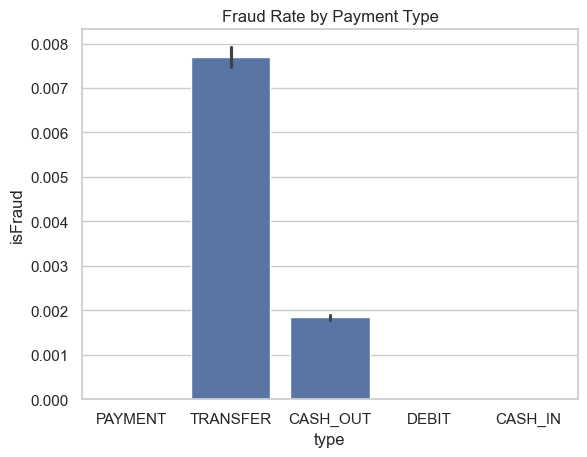

In [12]:
sns.barplot(data=df, x="type", y="isFraud")
plt.title("Fraud Rate by Payment Type")
plt.show()

Fraud shows up most often in TRANSFER and CASH_OUT transactions. TRANSFER has the highest fraud rate, while other forms of payment (besides CASH_OUT) show no fraud.